In [1]:
# Darstellung anpassen

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))



In [2]:
# Lade benötigte Programmpakete

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import sklearn as sk
import joblib


In [3]:
from sklearn.datasets import fetch_openml # Lade den MNIST_784-Datensatz
mnist=fetch_openml('mnist_784',as_frame=False,parser='auto')

In [4]:
X=mnist['data'] # Features, 
y=mnist['target'] # Labels
print(f"Shape of X: {X.shape}")
# Teile in Trainings und Test-Daten. Verwende die ersten 60000 Bilder zum trainieren und die letzten 10000 zum Testen
X_train=X[:60000,:]
y_train=y[:60000]
X_test=X[60000:,:]
y_test=y[60000:]



Shape of X: (70000, 784)


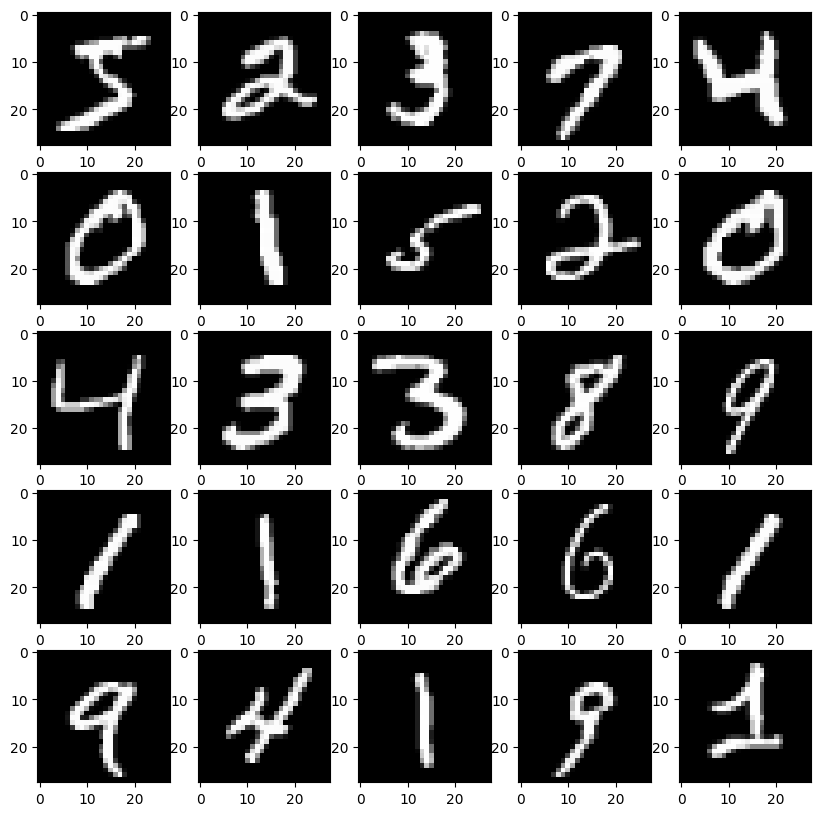

In [5]:
# Plotte Beispielbilder der Ziffern
fig,ax=plt.subplots(5,5,figsize=(10,10))
for i in range(25):
    j=i%5
    k=i//5

    test_image=X[i].reshape(28,28)
    ax[j,k].imshow(test_image,cmap='gray',vmin=0, vmax=255)

##### Entwickeln Sie einen Classifier der die Ziffer '5' erkennt. Verwenden Sie zur Entwicklung den Trainingsdatensatz X_train, y_train und verwenden Sie die in der LV besprochenen Methoden um ein optimales Modell mit optimalen Hyperparametern zu entwickeln. Erst wenn Sie fertig sind, und überzeugt das bestmögliche Modell gefunden zu haben, Werten Sie ihre Daten am Test-Datensatz aus. 

In [6]:
# Preprocsessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
print(scaler.fit(X_train))
print(scaler.data_max_)
print(scaler.transform(X_train))
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 
y_train_binary = (y_train == "5") # why is this a string???????
y_test_binary = (y_test == "5")


MinMaxScaler()
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 116. 254.
 216.   9.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.  16.  47. 157. 254. 255. 254. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 244. 255. 184. 197.   0.   0.   0.   0.
   0.   0.  64.  29. 134.  62. 234. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 165.   0.   0.
   0.   0. 141. 101.  96. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 192. 121.   0.
   0.  38. 144. 101. 254. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 254. 221.  63.
   0.   0.  95. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.  93.
   0.   7. 210. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 2

In [7]:
# basic training runs in single core => can take a while; C=10 ~ 2 minutes, used for prep
from sklearn.svm import SVC
basic_svc=SVC(C=10) # probability=True
basic_svc.fit(X_train_scaled, y_train_binary)
joblib.dump(basic_svc, "models/svc_model_binary_basic.joblib")

['models/svc_model_binary_basic.joblib']

Finding optimal Hyperparameters by using GridSearchCV, even when using a low amout of splits, parameters training takes a lot of time, even with parallization...      
1fit ~ 1:40


In [11]:
# binary
from sklearn.model_selection import GridSearchCV, KFold
# Creating a support vector classifier
svc=SVC(kernel='rbf') # probability=True for later use in the web app

cs = np.logspace(-1, 2, 4) 
gammas = np.logspace(-3, 1, 2)

params = {
    'C': cs,

}

gs_binary = GridSearchCV(svc, params, cv=KFold(n_splits=4), scoring = "balanced_accuracy", verbose=3, n_jobs=-1)#n_jobs=-1 => alle Kerne nutzen, einen thread für
gs_binary.fit(X_train_scaled, y_train_binary)

joblib.dump(gs_binary, "models/svc_model_binary_good.joblib")

Fitting 4 folds for each of 4 candidates, totalling 16 fits


['models/svc_model_binary_good.joblib']

In [12]:
# non biary, all digits
from sklearn.model_selection import GridSearchCV, KFold
# Creating a support vector classifier
svc=SVC(kernel='rbf')# probability=True

cs = np.logspace(-1, 2, 4) 
gammas = np.logspace(-3, -1, 2)
params = {
    'C': cs,
}

gs = GridSearchCV(svc, params, cv=KFold(n_splits=4), scoring = "balanced_accuracy", verbose=3, n_jobs=-1)#n_jobs=-1 => alle Kerne nutzen, einen thread für
gs.fit(X_train_scaled, y_train_binary)

joblib.dump(gs, "models/svc_model_good.joblib")

Fitting 4 folds for each of 4 candidates, totalling 16 fits


['models/svc_model_good.joblib']

In [13]:
svc = joblib.load("models/svc_model_binary_good.joblib")

Um die Rechenzeit für die Auswertung des Modells zu reduzieren werden Test und Trainingsdatensatz auf alle Kerne der CPU aufgeteilt um eine parallele berechnung zu ermöglichen.

In [14]:
import os
number_of_cpus = os.cpu_count()

In [ ]:
# 10 seconds
from joblib import Parallel, delayed

def batch_predict(model, X_batch):
    return model.predict(X_batch)

# Split data into 4 chunks
X_chunks = np.array_split(X_test_scaled, number_of_cpus)

# Predict in parallel
predictions = Parallel(n_jobs=number_of_cpus)(delayed(batch_predict)(svc, chunk) for chunk in X_chunks)

# Concatenate results
y_pred = np.concatenate(predictions)
accuracy = (y_pred == y_test_binary).mean()
print("Accuracy on test set:", accuracy)

Accuracy on test set: 0.9974


In [ ]:
# 10 seconds 
X_chunks = np.array_split(X_train_scaled, number_of_cpus-2)

# Predict in parallel
predictions = Parallel(n_jobs=number_of_cpus-2)(delayed(batch_predict)(svc, chunk) for chunk in X_chunks)

# Concatenate results
y_pred_train = np.concatenate(predictions)
accuracy = (y_pred_train == y_train_binary).mean()
print("Accuracy on train set:", accuracy)

Accuracy on train set: 0.9999833333333333


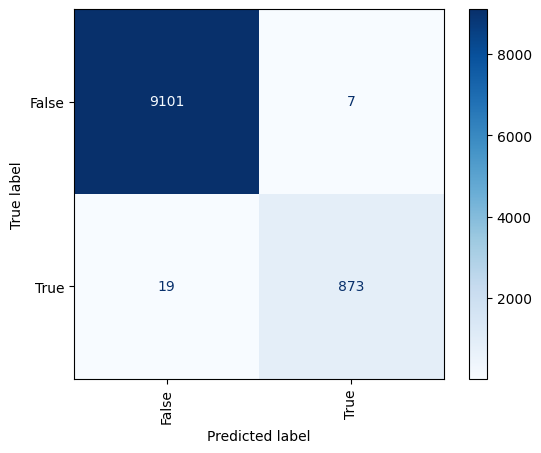

In [17]:
#gpt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_matrix = confusion_matrix(y_test_binary, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=svc.classes_)
cmd.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')


Fasle positives, False Negatives:

[ 449 1014 2185 2939 3567 3943 4536]
0 449
1 1014
2 2185
3 2939
4 3567


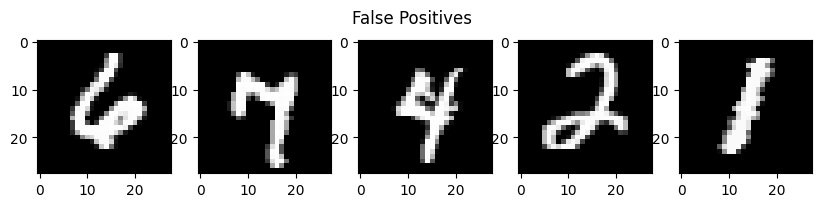

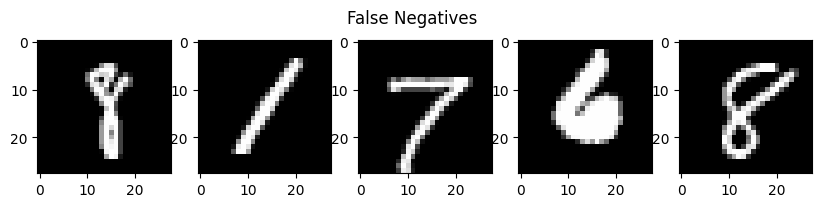

In [18]:
false_positives = np.where((y_test_binary == 0) & (y_pred == 1))[0]
false_negatives = np.where((y_test_binary == 1) & (y_pred == 0))[0]
print(false_positives)
false_positives = false_positives[:5]  # Limit to 5 for display
false_negatives = false_negatives[:5]  # Limit to 5 for display

fig,ax=plt.subplots(1,5,figsize=(10,2))
fig.suptitle("False Positives")
for id, i in enumerate(false_positives):
    print(id, i)
    test_image=X[i].reshape(28,28)
    ax[id].imshow(test_image,cmap='gray',vmin=0, vmax=255)

fig,ax=plt.subplots(1,5,figsize=(10,2))
fig.suptitle("False Negatives")
for id, i in enumerate(false_negatives):
    test_image=X[i].reshape(28,28)
    ax[id].imshow(test_image,cmap='gray',vmin=0, vmax=255)

Fehlererklärung TODO mit finalem Modell